<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/NLP_On_Fake_New_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

from wordcloud import WordCloud
import joblib

In [ ]:
df = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')
df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [ ]:
df.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [ ]:
df['subject'].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [ ]:
df['content'] = df['title'] + " " +df['text']

In [ ]:
df.head()

,title,text,subject,date,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Pope Francis Just Called Out Donald Trump Dur...


In [ ]:
df['length'] = df['content'].apply(len)

In [ ]:
df.head()

,title,text,subject,date,content,length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Donald Trump Sends Out Embarrassing New Year’...,2973
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Drunk Bragging Trump Staffer Started Russian ...,1968
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Sheriff David Clarke Becomes An Internet Joke...,3688
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Trump Is So Obsessed He Even Has Obama’s Name...,2853
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Pope Francis Just Called Out Donald Trump Dur...,2417


In [ ]:
df['word_count'] = df['content'].apply(lambda x:len(x.split()))

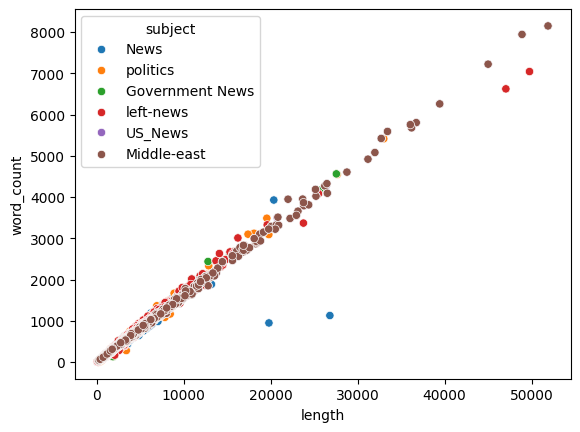

In [ ]:
sns.scatterplot(data=df, x='length',y='word_count',hue='subject')
plt.show()

In [ ]:
import plotly.express as px
fig = px.scatter_3d(df, x='length', y='word_count', z='subject')
fig.show()

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import re
import string
from nltk.corpus import stopwords as nltk_stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

stop_words = set(nltk_stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)

    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)



In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
nltk.download('punkt_tab')
df['clean_text'] = df['content'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df.head()

,title,text,subject,date,content,length,word_count,clean_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Donald Trump Sends Out Embarrassing New Year’...,2973,507,donald trump send embarrass new year ’ eve mes...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Drunk Bragging Trump Staffer Started Russian ...,1968,313,drunk brag trump staffer start russian collus ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Sheriff David Clarke Becomes An Internet Joke...,3688,595,sheriff david clark becom internet joke threat...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Trump Is So Obsessed He Even Has Obama’s Name...,2853,458,trump obsess even obama ’ name code websit ima...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Pope Francis Just Called Out Donald Trump Dur...,2417,431,pope franci call donald trump christma speech ...


In [ ]:
df['avg_word_len'] = df['content'].apply(lambda x: np.mean([len(w) for w in x.split()]))

In [ ]:
df.head()

,title,text,subject,date,content,length,word_count,clean_text,avg_word_len
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Donald Trump Sends Out Embarrassing New Year’...,2973,507,donald trump send embarrass new year ’ eve mes...,4.822485
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Drunk Bragging Trump Staffer Started Russian ...,1968,313,drunk brag trump staffer start russian collus ...,5.274760
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Sheriff David Clarke Becomes An Internet Joke...,3688,595,sheriff david clark becom internet joke threat...,5.164706
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Trump Is So Obsessed He Even Has Obama’s Name...,2853,458,trump obsess even obama ’ name code websit ima...,5.161572
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Pope Francis Just Called Out Donald Trump Dur...,2417,431,pope franci call donald trump christma speech ...,4.575406


In [ ]:
df['exclamation_count'] = df['content'].apply(lambda x:x.count('!'))

In [ ]:
df.head()

,title,text,subject,date,content,length,word_count,clean_text,avg_word_len,exclamation_count
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Donald Trump Sends Out Embarrassing New Year’...,2973,507,donald trump send embarrass new year ’ eve mes...,4.822485,6
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Drunk Bragging Trump Staffer Started Russian ...,1968,313,drunk brag trump staffer start russian collus ...,5.274760,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Sheriff David Clarke Becomes An Internet Joke...,3688,595,sheriff david clark becom internet joke threat...,5.164706,2
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Trump Is So Obsessed He Even Has Obama’s Name...,2853,458,trump obsess even obama ’ name code websit ima...,5.161572,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Pope Francis Just Called Out Donald Trump Dur...,2417,431,pope franci call donald trump christma speech ...,4.575406,0


In [ ]:
df['capital_ratio'] = df['content'].apply(lambda x:sum(1 for w in x.split())/len(x.split()))

In [ ]:
df.head()

,title,text,subject,date,content,length,word_count,clean_text,avg_word_len,exclamation_count,capital_ratio
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Donald Trump Sends Out Embarrassing New Year’...,2973,507,donald trump send embarrass new year ’ eve mes...,4.822485,6,1.0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Drunk Bragging Trump Staffer Started Russian ...,1968,313,drunk brag trump staffer start russian collus ...,5.274760,0,1.0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Sheriff David Clarke Becomes An Internet Joke...,3688,595,sheriff david clark becom internet joke threat...,5.164706,2,1.0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Trump Is So Obsessed He Even Has Obama’s Name...,2853,458,trump obsess even obama ’ name code websit ima...,5.161572,0,1.0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Pope Francis Just Called Out Donald Trump Dur...,2417,431,pope franci call donald trump christma speech ...,4.575406,0,1.0


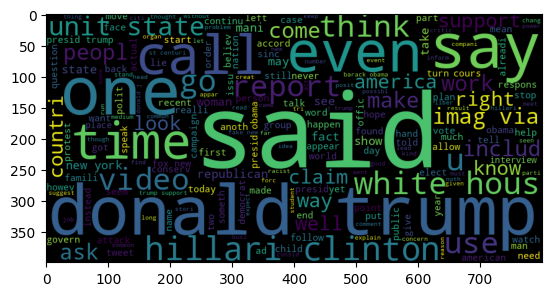

In [ ]:
all_words = " ".join(df['clean_text'])
wc = WordCloud(width=800, height=400).generate(all_words)
plt.imshow(wc)
plt.axis=('off')
plt.show()

In [ ]:
X = df['clean_text']
y = df['subject']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
ngram = TfidfVectorizer(ngram_range=(1,2), max_features = 5000)

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_tfidf,y_train)
pred_nb = nb.predict(X_test_tfidf)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.svm import LinearSVC
svm = LinearSVC()
svm.fit(X_train_tfidf,y_train)

LinearSVC()

In [ ]:
print(classification_report(y_test,pred_nb))

                 precision    recall  f1-score   support

Government News       0.28      0.06      0.10       316
    Middle-east       0.21      0.13      0.16       159
           News       0.73      0.95      0.82      1821
        US_News       0.11      0.06      0.07       160
      left-news       0.34      0.15      0.21       897
       politics       0.47      0.59      0.52      1344

       accuracy                           0.57      4697
      macro avg       0.36      0.32      0.31      4697
   weighted avg       0.51      0.57      0.52      4697



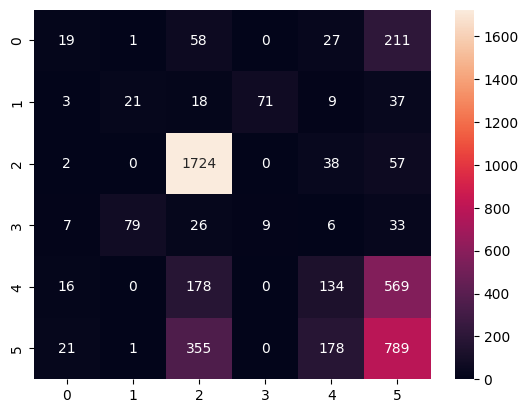

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred_nb), annot=True, fmt="d")
plt.show()

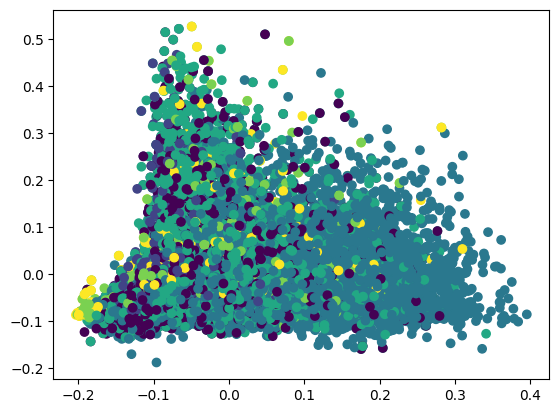

In [ ]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_tfidf.toarray())
plt.scatter(X_2d[:,0], X_2d[:,1], c=pd.factorize(y_train)[0])
plt.show(

)

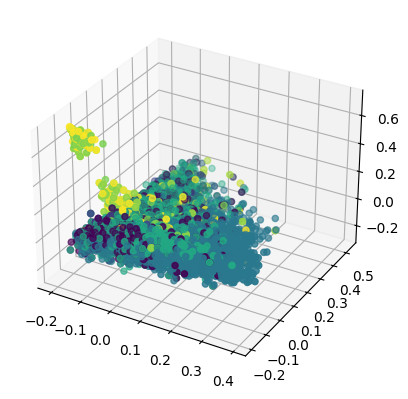

In [ ]:
pca3 = PCA(n_components=3)
X_3d = pca3.fit_transform(X_train_tfidf.toarray())
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],c=pd.factorize(y_train)[0])
plt.show()

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
from nltk import pos_tag
from nltk.tokenize import word_tokenize

tokens = word_tokenize(df['content'][0])
print(pos_tag(tokens))

[('Donald', 'NNP'), ('Trump', 'NNP'), ('Sends', 'VBZ'), ('Out', 'RP'), ('Embarrassing', 'VBG'), ('New', 'NNP'), ('Year', 'NNP'), ('’', 'NNP'), ('s', 'VBD'), ('Eve', 'NNP'), ('Message', 'NNP'), (';', ':'), ('This', 'DT'), ('is', 'VBZ'), ('Disturbing', 'VBG'), ('Donald', 'NNP'), ('Trump', 'NNP'), ('just', 'RB'), ('couldn', 'VB'), ('t', 'JJ'), ('wish', 'JJ'), ('all', 'DT'), ('Americans', 'NNPS'), ('a', 'DT'), ('Happy', 'JJ'), ('New', 'NNP'), ('Year', 'NNP'), ('and', 'CC'), ('leave', 'VB'), ('it', 'PRP'), ('at', 'IN'), ('that', 'DT'), ('.', '.'), ('Instead', 'RB'), (',', ','), ('he', 'PRP'), ('had', 'VBD'), ('to', 'TO'), ('give', 'VB'), ('a', 'DT'), ('shout', 'NN'), ('out', 'IN'), ('to', 'TO'), ('his', 'PRP$'), ('enemies', 'NNS'), (',', ','), ('haters', 'NNS'), ('and', 'CC'), ('the', 'DT'), ('very', 'RB'), ('dishonest', 'JJS'), ('fake', 'JJ'), ('news', 'NN'), ('media', 'NNS'), ('.', '.'), ('The', 'DT'), ('former', 'JJ'), ('reality', 'NN'), ('show', 'NN'), ('star', 'NN'), ('had', 'VBD'), ('

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(df["content"][0])

for ent in doc.ents:
    print(ent.text, ent.label_)

Donald Trump Sends Out PERSON
Embarrassing New Year’s Eve Message EVENT
Donald Trump PERSON
Americans NORP
New Year EVENT
one CARDINAL
Fake News Media ORG
Angry Pants PERSON
2018 DATE
a great year DATE
America GPE
Fake News Media ORG
2018 DATE
a great year DATE
America GPE
Donald J. Trump PERSON
December 31 DATE
2017Trump s tweet QUANTITY
New Year EVENT
Trump PERSON
American NORP
new year DATE
Talbert Swan PERSON
December 31, 2017no DATE
Calvin PERSON
December 31 DATE
2017Your CARDINAL
2018 DATE
America GPE
Congress ORG
Miranda Yaver PERSON
December 31 DATE
2017Do CARDINAL
Alan Sandoval PERSON
@AlanSandoval13 GPE
December 31 DATE
2017Who CARDINAL
Haters ORG
New Years EVENT
Marlene PERSON
December 31 DATE
new year DATE
Koren PERSON
December 31 DATE
Trump s New Year s Eve ORG
New Year EVENT
Donald J. Trump PERSON
December 31 DATE
Trump PERSON
years DATE
Trump ORG
New Year s EVENT
Easter GPE
Thanksgiving DATE
9/11 CARDINAL
pic.twitter.com/4FPAe2KypA ORG
Daniel Dale PERSON
@ddale8 ORG
Dece

In [ ]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression())
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression())])

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {
    "tfidf__max_features":[3000,5000],
    "clf__C":[0.1,1,10]
}

grid = GridSearchCV(pipeline, params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/

{'clf__C': 1, 'tfidf__max_features': 3000}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [ ]:
final_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression())
])

final_model.fit(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression())])

In [ ]:
joblib.dump(final_model, "fake_news_subject_classifier.pkl")

['fake_news_subject_classifier.pkl']